This Note book will use the preprocessed data to train Random forest, once on after pcs and once before. Then comaprison will be made to select the overall m=better model to use for this application.

CV will be used across both models to determine the best hyperparanmeters


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [81]:
from google.colab import drive
drive.mount('/content/drive')

PATH = '/content/drive/MyDrive/Datasets'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset

We will have 2 datasets that we will work on for comparision, one is the original codon usage sataset, the other is after applying pca

In [82]:
# Path for both datasets
data_path = f'{PATH}/Pre_PCA.csv'
data_pca_path = f'{PATH}/pca_results.csv'

# Read both datasets
df = pd.read_csv(data_path)
df_pca = pd.read_csv(data_pca_path)

### Split each to X y & train test

In [83]:
# Pre-PCA Dataset
y = df['Kingdom']
X = df.drop('Kingdom', axis= 1)

# Train test split
X_train , X_test , y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2, stratify=y)


In [84]:
# PCA Dataset
yp = df_pca['Kingdom']
Xp = df_pca.drop('Kingdom', axis= 1)

# Train test split
Xp_train , Xp_test , yp_train, yp_test = train_test_split(Xp, yp, random_state= 42, test_size= 0.2, stratify=yp)


## Cross Vaildation

We already have preprocessed data, so we will move on to determining hyperparameters using cross validation. The relevant hyperparameters we will look into in the RandomForest are as follow:

*   n_estimators
*   criterion : gini (faster) , entropy (more balanced)
*   max_depth
*   min_samples_split




In [85]:
model = RandomForestClassifier(random_state= 42)

params = {
    'n_estimators' : [100, 150],
    'max_depth' : [None , 10 ],
    'min_samples_split' : [2 , 5]
}

# Create 2 grid search instances to later access both attributes
grid_search = GridSearchCV(estimator= model, param_grid= params, scoring= 'f1_macro', cv = 5)
grid_search_pca = GridSearchCV(estimator= model, param_grid= params, scoring= 'f1_macro', cv = 5)

In [86]:
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.8461471049200732


In [87]:
grid_search_pca.fit(Xp_train, yp_train)

print(f"Best Parameters: {grid_search_pca.best_params_}")
print(f"Best Score: {grid_search_pca.best_score_}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.8384620037362035


The pre-PCA data gave the better score in training , but the PCA data required less training time, and the score is almost the same hence the increased computaions from the pre-PCA data (which is due to having more features) makes the PCA data the winnning candidate.

We care about computaion load for the sake of scaling the model, and training it on more data in the future

## Evaluation

### Pre-PCA Dataset

In [106]:
# Get the best pre-PCA model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [107]:
score = best_model.score(X_test, y_test) * 100
print(f"Testing Score for pre PCA data: {score:.2f}")

Testing Score for pre PCA data: 91.43


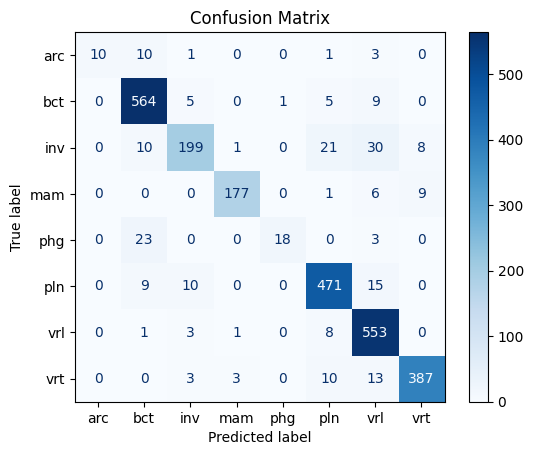

In [108]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')

# Save the CM as an image
plt.title("Confusion Matrix")
plt.savefig('Random Forest_confusion matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [98]:
report = classification_report(y_test, y_pred)

# Print title
print(" "* 20 + "   CLASSIFICATION REPORT\n")

# Print report
print(report)

                       CLASSIFICATION REPORT

              precision    recall  f1-score   support

         arc       1.00      0.40      0.57        25
         bct       0.91      0.97      0.94       584
         inv       0.90      0.74      0.81       269
         mam       0.97      0.92      0.94       193
         phg       0.95      0.41      0.57        44
         pln       0.91      0.93      0.92       505
         vrl       0.88      0.98      0.92       566
         vrt       0.96      0.93      0.94       416

    accuracy                           0.91      2602
   macro avg       0.93      0.78      0.83      2602
weighted avg       0.92      0.91      0.91      2602



### PCA Dataset

In [99]:
# Get the best PCS model
best_model_pca = grid_search_pca.best_estimator_

yp_pred = best_model_pca.predict(Xp_test)

In [100]:
score_p = best_model_pca.score(Xp_test, yp_test) * 100
print(f"Testing Score for PCA data: {score_p:.2f}")

Testing Score for PCA data: 90.20


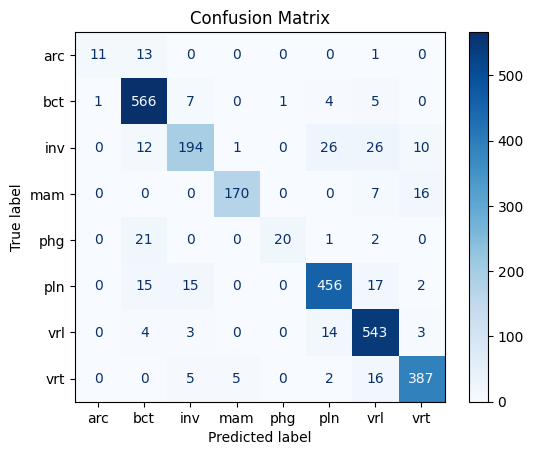

In [109]:
# Confusion Matrix
cm_p = confusion_matrix(yp_test, yp_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_p, display_labels=best_model_pca.classes_)
disp.plot(cmap='Blues')

# Save the CM as an image
plt.title("Confusion Matrix")
plt.savefig('Random Forest_confusion matrix PCA.png', dpi=300, bbox_inches='tight')
plt.show()

In [102]:
report_pca = classification_report(yp_test, yp_pred)

# Print title
print(" "* 17 + "   CLASSIFICATION REPORT PCA\n")

# Print report
print(report_pca)

                    CLASSIFICATION REPORT PCA

              precision    recall  f1-score   support

         arc       0.92      0.44      0.59        25
         bct       0.90      0.97      0.93       584
         inv       0.87      0.72      0.79       269
         mam       0.97      0.88      0.92       193
         phg       0.95      0.45      0.62        44
         pln       0.91      0.90      0.90       505
         vrl       0.88      0.96      0.92       567
         vrt       0.93      0.93      0.93       415

    accuracy                           0.90      2602
   macro avg       0.91      0.78      0.83      2602
weighted avg       0.90      0.90      0.90      2602



## Saving the model

As we saw the accuracy of both Pre- and post- PCA datasets have similar accuracies, with the pre-PCA being slightly higher, but the PCA had lower computation cost, hence we will export the PCA model for later use, specifically to add in an Ensemble of models.

In [104]:
import pickle as pk
def save_model(saved_model , filename):
    with open(f"{filename}.pkl" , "wb") as f:
        pk.dump(saved_model , f)

def load_model(filename):
    with open(f"{filename}.pkl" , "rb") as f:
        saved_model = pk.load(f)
    return saved_model

In [105]:
filename = "RF_model"
save_model(best_model_pca, filename)